In [1]:
# Import des bibliothèques nécessaires
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, accuracy_score
import matplotlib.pyplot as plt



## Régression

In [2]:
# Génération de données simples pour la régression
np.random.seed(0)
X_reg = np.random.rand(100, 1) * 10  # Feature : une variable aléatoire continue entre 0 et 10
y_reg = X_reg[:, 0] * np.sin(X_reg[:, 0]) + np.random.randn(100) * 0.5  # Target : fonction sinus avec bruit

# Séparation des données en train et test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


Erreur quadratique moyenne (MSE) - Régression :
Arbre de décision : 0.42
Bagging : 0.39
Forêt aléatoire : 0.39
Boosting : 0.41


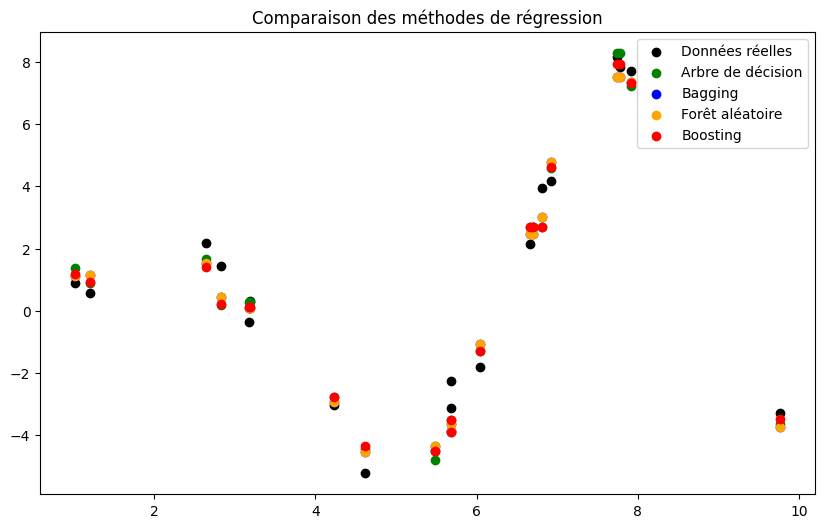

In [4]:

# Arbre de décision (régression)
tree_reg = DecisionTreeRegressor()
tree_reg.fit(X_train_reg, y_train_reg)
y_pred_tree_reg = tree_reg.predict(X_test_reg)

# Bagging (régression)
bagging_reg = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=10, random_state=42)
bagging_reg.fit(X_train_reg, y_train_reg)
y_pred_bagging_reg = bagging_reg.predict(X_test_reg)

# Forêt aléatoire (régression)
rf_reg = RandomForestRegressor(n_estimators=10, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

# Boosting (régression)
boosting_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
boosting_reg.fit(X_train_reg, y_train_reg)
y_pred_boosting_reg = boosting_reg.predict(X_test_reg)

# Affichage des résultats de la régression
print("Erreur quadratique moyenne (MSE) - Régression :")
print(f"Arbre de décision : {mean_squared_error(y_test_reg, y_pred_tree_reg):.2f}")
print(f"Bagging : {mean_squared_error(y_test_reg, y_pred_bagging_reg):.2f}")
print(f"Forêt aléatoire : {mean_squared_error(y_test_reg, y_pred_rf_reg):.2f}")
print(f"Boosting : {mean_squared_error(y_test_reg, y_pred_boosting_reg):.2f}")

# Visualisation des prédictions pour la régression
plt.figure(figsize=(10, 6))
plt.scatter(X_test_reg, y_test_reg, color='black', label="Données réelles")
plt.scatter(X_test_reg, y_pred_tree_reg, label="Arbre de décision", color='green')
plt.scatter(X_test_reg, y_pred_bagging_reg, label="Bagging", color='blue')
plt.scatter(X_test_reg, y_pred_rf_reg, label="Forêt aléatoire", color='orange')
plt.scatter(X_test_reg, y_pred_boosting_reg, label="Boosting", color='red')
plt.legend()
plt.title("Comparaison des méthodes de régression")
plt.show()



## Classification

In [6]:
# Génération de données simples pour la classification
X_class = np.random.rand(100, 2) * 10  # Deux variables continues
y_class = (X_class[:, 0] + X_class[:, 1] > 10).astype(int)  # Classe 0 ou 1 en fonction de la somme des features

# Séparation des données en train et test
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Arbre de décision (classification)
tree_class = DecisionTreeClassifier()
tree_class.fit(X_train_class, y_train_class)
y_pred_tree_class = tree_class.predict(X_test_class)

# Bagging (classification)
bagging_class = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=42)
bagging_class.fit(X_train_class, y_train_class)
y_pred_bagging_class = bagging_class.predict(X_test_class)

# Forêt aléatoire (classification)
rf_class = RandomForestClassifier(n_estimators=10, random_state=42)
rf_class.fit(X_train_class, y_train_class)
y_pred_rf_class = rf_class.predict(X_test_class)





Précision - Classification :
Arbre de décision : 0.95
Bagging : 0.90
Forêt aléatoire : 0.95
Boosting : 0.95


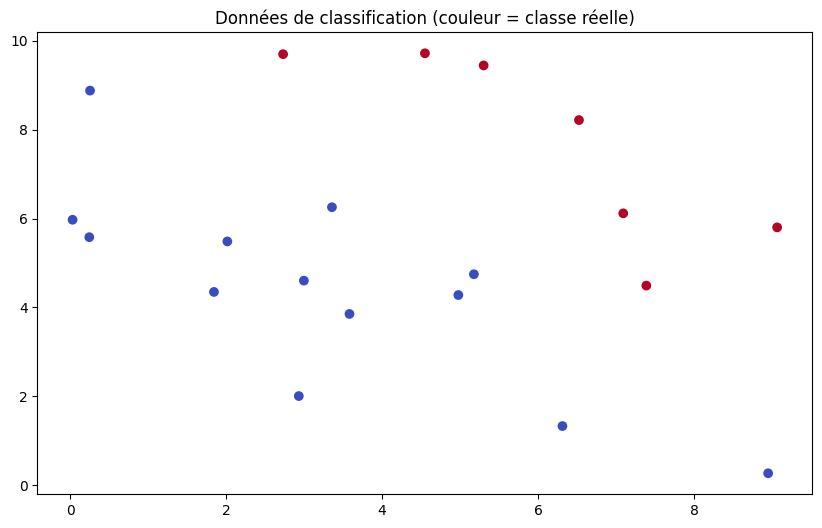

In [7]:
# Boosting (classification)
boosting_class = GradientBoostingClassifier(n_estimators=100, random_state=42)
boosting_class.fit(X_train_class, y_train_class)
y_pred_boosting_class = boosting_class.predict(X_test_class)

# Affichage des résultats de la classification
print("\nPrécision - Classification :")
print(f"Arbre de décision : {accuracy_score(y_test_class, y_pred_tree_class):.2f}")
print(f"Bagging : {accuracy_score(y_test_class, y_pred_bagging_class):.2f}")
print(f"Forêt aléatoire : {accuracy_score(y_test_class, y_pred_rf_class):.2f}")
print(f"Boosting : {accuracy_score(y_test_class, y_pred_boosting_class):.2f}")

# Visualisation des prédictions pour la classification
plt.figure(figsize=(10, 6))
plt.scatter(X_test_class[:, 0], X_test_class[:, 1], c=y_test_class, label="Données réelles", cmap="coolwarm")
plt.title("Données de classification (couleur = classe réelle)")
plt.show()